<a href="https://colab.research.google.com/github/gap1070/cs417-labs/blob/main/Lab11/notebooks/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 11: Sorting Analysis
In this notebook you'll visualize how sorting algorithms work, measure their performance, and discover why Big-O isn't the whole story.

Before you start: Paste your completed sort functions into the cell below.

In [1]:
def bubble_sort(a_list):
    n = len(a_list)

    for i in range(n-1):
        for j in range(n-1-i):
            if a_list[j] > a_list[j + 1]:
                a_list[j], a_list[j + 1] = a_list[j + 1], a_list[j]

    return a_list

def short_bubble_sort(a_list):
    n = len(a_list)

    for i in range(n -1):
        swapped = False

        for j in range(n - 1 - i):
            if a_list[j] > a_list[j + 1]:
                a_list[j], a_list[j + 1] = a_list[j + 1], a_list[j]
                swapped = True

        if not swapped:
            break

    return a_list

def insertion_sort(a_list):
    for i in range(1, len(a_list)):
        current_value = a_list[i]
        position = i - 1

        while position >= 0 and a_list[position] > current_value:
            a_list[position + 1] = a_list[position]
            position -= 1

        a_list[position + 1] = current_value

    return a_list

def bubble_sort_counted(a_list):
    n = len(a_list)
    comparisons = 0
    exchanges = 0

    for i in range(n - 1):
        for j in range(n - 1 - i):
            comparisons += 1
            if a_list[j] > a_list[j + 1]:
                a_list[j], a_list[j + 1] = a_list[j + 1], a_list[j]
                exchanges += 1

    return a_list, comparisons, exchanges


def insertion_sort_counted(a_list):
    comparisons = 0
    data_moves = 0

    for i in range(1, len(a_list)):
        current_value = a_list[i]
        position = i - 1

        while position >= 0:
            comparisons += 1
            if a_list[position] > current_value:
                a_list[position + 1] = a_list[position]
                data_moves += 1
                position -= 1
            else:
                break

        a_list[position + 1] = current_value
        data_moves += 1

    return a_list, comparisons, data_moves

In [2]:
# Quick sanity check — run this to make sure your functions work
assert bubble_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "bubble_sort failed"
assert short_bubble_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "short_bubble_sort failed"
assert insertion_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "insertion_sort failed"

r1, c1, e1 = bubble_sort_counted([3, 1, 2])
assert r1 == [1, 2, 3], "bubble_sort_counted failed"

r2, c2, d2 = insertion_sort_counted([3, 1, 2])
assert r2 == [1, 2, 3], "insertion_sort_counted failed"

print("All functions working!")

All functions working!


Experiment 1: Watching the Mechanism
Before we measure performance, let's see how each algorithm sorts. The helper functions below print the list after every pass so you can watch the progress.

In [3]:
def bubble_sort_visual(a_list):
    """Bubble sort with a printout after each pass."""
    a_list = a_list[:]  # work on a copy
    n = len(a_list)
    print(f"Start:  {a_list}")
    for i in range(n - 1):
        for j in range(n - 1 - i):
            if a_list[j] > a_list[j + 1]:
                a_list[j], a_list[j + 1] = a_list[j + 1], a_list[j]
        # Show sorted vs unsorted regions
        sorted_start = n - 1 - i
        unsorted = a_list[:sorted_start]
        sorted_part = a_list[sorted_start:]
        print(f"Pass {i+1}: {unsorted} | {sorted_part}")
    return a_list


def insertion_sort_visual(a_list):
    """Insertion sort with a printout after each pass."""
    a_list = a_list[:]  # work on a copy
    n = len(a_list)
    print(f"Start:  {a_list}")
    for i in range(1, n):
        current_value = a_list[i]
        position = i - 1
        while position >= 0 and a_list[position] > current_value:
            a_list[position + 1] = a_list[position]
            position -= 1
        a_list[position + 1] = current_value
        # Show sorted vs unsorted regions
        sorted_part = a_list[:i + 1]
        unsorted = a_list[i + 1:]
        print(f"Pass {i}: {sorted_part} | {unsorted}")
    return a_list

In [4]:
test_list = [54, 26, 93, 17, 77, 31, 44, 55, 20]

print("=" * 50)
print("BUBBLE SORT")
print("=" * 50)
bubble_sort_visual(test_list)

print()
print("=" * 50)
print("INSERTION SORT")
print("=" * 50)
insertion_sort_visual(test_list)


BUBBLE SORT
Start:  [54, 26, 93, 17, 77, 31, 44, 55, 20]
Pass 1: [26, 54, 17, 77, 31, 44, 55, 20] | [93]
Pass 2: [26, 17, 54, 31, 44, 55, 20] | [77, 93]
Pass 3: [17, 26, 31, 44, 54, 20] | [55, 77, 93]
Pass 4: [17, 26, 31, 44, 20] | [54, 55, 77, 93]
Pass 5: [17, 26, 31, 20] | [44, 54, 55, 77, 93]
Pass 6: [17, 26, 20] | [31, 44, 54, 55, 77, 93]
Pass 7: [17, 20] | [26, 31, 44, 54, 55, 77, 93]
Pass 8: [17] | [20, 26, 31, 44, 54, 55, 77, 93]

INSERTION SORT
Start:  [54, 26, 93, 17, 77, 31, 44, 55, 20]
Pass 1: [26, 54] | [93, 17, 77, 31, 44, 55, 20]
Pass 2: [26, 54, 93] | [17, 77, 31, 44, 55, 20]
Pass 3: [17, 26, 54, 93] | [77, 31, 44, 55, 20]
Pass 4: [17, 26, 54, 77, 93] | [31, 44, 55, 20]
Pass 5: [17, 26, 31, 54, 77, 93] | [44, 55, 20]
Pass 6: [17, 26, 31, 44, 54, 77, 93] | [55, 20]
Pass 7: [17, 26, 31, 44, 54, 55, 77, 93] | [20]
Pass 8: [17, 20, 26, 31, 44, 54, 55, 77, 93] | []


[17, 20, 26, 31, 44, 54, 55, 77, 93]

Experiment 1 Questions
Study the output above and answer these questions:

Q1: In bubble sort, where do the sorted items accumulate — the left end or the right end of the list? In insertion sort, where do they accumulate?

Your answer: IN the bubble sort they accumulate at the end, where the sytem puts the biggest number of the numbers. In insertion sort they accumulate at the begining, where the algorithm takes two elements, sorts bigger and smaller, then adds the next number to the set.

Q2: Watch bubble sort's first few passes. How much does the unsorted region shrink after each pass? Now watch insertion sort — how much does the sorted region grow after each pass?

Your answer: For bubble sort it only chnages by one every single time since it just pulls out the largest number each time. In insertion there are 2 numbers taken the first time to start the algorithm but for the rest of the passes its just one.

Q3: Which algorithm's progress is easier to follow visually? Why do you think that is?

Your answer: To follow visually i would have to say insertion, but because it is showing us sorting like we would normally do with cards or something going from right to left.



Experiment 2: The Comparison Race
Now let's measure. We'll run both counted sort functions on randomly generated lists of increasing size and plot comparisons and data moves separately.

In [5]:
import random
import matplotlib.pyplot as plt

sizes = [100, 500, 1000, 5000]
bubble_comps = []
bubble_moves = []
insertion_comps = []
insertion_moves = []

for n in sizes:
    data = list(range(n))
    random.shuffle(data)

    _, bc, be = bubble_sort_counted(data[:])
    _, ic, im = insertion_sort_counted(data[:])

    bubble_comps.append(bc)
    bubble_moves.append(be)
    insertion_comps.append(ic)
    insertion_moves.append(im)

    print(f"n={n:>5}: Bubble comps={bc:>10,}  exchanges={be:>10,}  |  Insertion comps={ic:>10,}  data_moves={im:>10,}")

n=  100: Bubble comps=     4,950  exchanges=     2,615  |  Insertion comps=     2,711  data_moves=     2,714
n=  500: Bubble comps=   124,750  exchanges=    63,367  |  Insertion comps=    63,861  data_moves=    63,866
n= 1000: Bubble comps=   499,500  exchanges=   242,633  |  Insertion comps=   243,630  data_moves=   243,632
n= 5000: Bubble comps=12,497,500  exchanges= 6,146,619  |  Insertion comps= 6,151,608  data_moves= 6,151,618


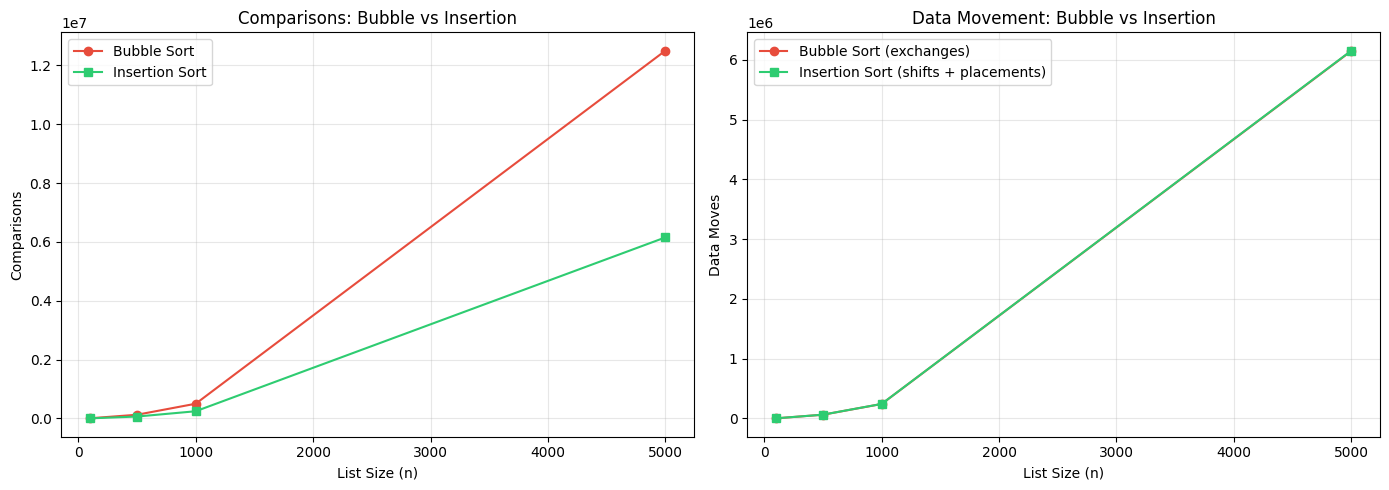

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Comparisons
ax1.plot(sizes, bubble_comps, 'o-', label='Bubble Sort', color='#e74c3c')
ax1.plot(sizes, insertion_comps, 's-', label='Insertion Sort', color='#2ecc71')
ax1.set_xlabel('List Size (n)')
ax1.set_ylabel('Comparisons')
ax1.set_title('Comparisons: Bubble vs Insertion')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Data moves
ax2.plot(sizes, bubble_moves, 'o-', label='Bubble Sort (exchanges)', color='#e74c3c')
ax2.plot(sizes, insertion_moves, 's-', label='Insertion Sort (shifts + placements)', color='#2ecc71')
ax2.set_xlabel('List Size (n)')
ax2.set_ylabel('Data Moves')
ax2.set_title('Data Movement: Bubble vs Insertion')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Experiment 2 Questions
Q1: Look at the comparisons graph. Do bubble sort and insertion sort make roughly the same number of comparisons, or is one consistently higher? Does this match what you'd expect from their shared O(n^2) classification?

Your answer: Bubble sort does roughly half more comparisons that insertion sort. This is a little interesting since they do both share the 0(n^2) classification, I did not expect this. I thought they would have had more similar comparison numbers.

Q2: Now look at the data moves graph. What do you see? Which algorithm moves data more efficiently?

Your answer: The data moves graph shows that insertion sort has alot more data moves that it since bubble sort isnt even on the graph. Bubble sort perfoms less exhanges than insertion does but exchanges represent three assigments.

Q3: If comparisons are roughly equal but data movement is very different, what does that tell you about using Big-O alone to predict real-world performance?

Your answer: I think this experiment is to show us that big O is used to show us the graph rate, not how well it performs. Both of these algorithms are n^2 but bubble short does way more comparisons, and it goes the other way for data moves.

Experiment 3: Best Case, Worst Case
Not all inputs are created equal. Let's see how each algorithm handles the best case (already sorted), worst case (reverse sorted), and average case (random).

In [7]:
n = 1000

already_sorted = list(range(n))
reverse_sorted = list(range(n - 1, -1, -1))
random_list = list(range(n))
random.shuffle(random_list)

cases = {
    "Already sorted": already_sorted,
    "Reverse sorted": reverse_sorted,
    "Random": random_list,
}

print(f"{'Case':<20} {'Algorithm':<15} {'Comparisons':>12} {'Data Moves':>12}")
print("-" * 62)

for case_name, data in cases.items():
    _, bc, be = bubble_sort_counted(data[:])
    _, ic, im = insertion_sort_counted(data[:])
    print(f"{case_name:<20} {'Bubble':<15} {bc:>12,} {be:>12,}")
    print(f"{'':<20} {'Insertion':<15} {ic:>12,} {im:>12,}")
    print()

Case                 Algorithm        Comparisons   Data Moves
--------------------------------------------------------------
Already sorted       Bubble               499,500            0
                     Insertion                999          999

Reverse sorted       Bubble               499,500      499,500
                     Insertion            499,500      500,499

Random               Bubble               499,500      253,927
                     Insertion            254,920      254,926



Experiment 3 Questions
Q1: Which sort benefits the most from already-sorted input? Look at both comparisons and data moves — does either drop dramatically?

Your answer: Insertion sort benefits alot with already sorted inputs. This sort perfoms only one comparison for every pass it does and there are no shifts, so if its given an already sorted list it acutally becomes a O(n) algorithm.

Q2: On reverse-sorted input, which sort performs worst? Why does that specific input cause the most work for that algorithm?

Your answer: Both algorithms work really badly with reverse sorted lists. This happens because every element in a reverse sorted list is far away from its correct position so it takes a long time.

Q3: If you knew your data was almost sorted — say, one or two items out of place — which algorithm would you choose: bubble sort, short bubble sort, or insertion sort? Why? Think about your short bubble implementation — how would it handle nearly-sorted input?

Your answer: If the data is almost sorted I would have to say insertion would be the best. It doesnt have to do much work when elements are close to there position so it makes it work with less comparisons, in this scenario.